In [2]:
import math
import sys
import mpire
import os

os.environ["OMP_NUM_THREADS"] = "1"
import time
import multiprocessing
from mpire import WorkerPool
from pprint import pprint
import itertools
num_cores =max(multiprocessing.cpu_count()//2,1)
import shutil
import random
from multiprocessing import Manager
from pprint import pprint

from ragatouille import RAGPretrainedModel


from sentence_transformers import SentenceTransformer
from voyager import Index, Space

import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

from ragatouille.utils import get_wikipedia_page
from ragatouille.data import CorpusProcessor

class MyExistingRetrievalPipeline:
    index: Index
    embedder: SentenceTransformer

    def __init__(self, embedder_name: str = "BAAI/bge-small-en-v1.5"):
        self.embedder = SentenceTransformer(embedder_name)
        self.collection_map = {}
        self.index = Index(
            Space.Cosine,
            num_dimensions=self.embedder.get_sentence_embedding_dimension(),
        )

    def index_documents(self, documents: list[str]) -> None:
        # There's very few documents in our example, so we don't bother with batching
        for document in documents:
            self.collection_map[self.index.add_item(self.embedder.encode(document['content']))] = document['content']

    def query(self, query: str, k: int = 10) -> list[str]:
        query_embedding = self.embedder.encode(query)
        to_return = []
        for idx in self.index.query(query_embedding, k=k)[0]:
            to_return.append(self.collection_map[idx])
        return to_return






def parallel_process_recipe(get_wikipedia_pages):
    # print(f"get_wikipedia_pages: {get_wikipedia_pages}")
    recipe = get_wikipedia_page(get_wikipedia_pages)
    return {"individual_recipe":recipe}


def create_recipe(recipe_items):
    top_n_recipes = 1
    RAG = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")
    existing_pipeline = MyExistingRetrievalPipeline()

    corpus_processor = CorpusProcessor()
    actual_recipe = "Create a recipe like ratatouille from:-"
    recipe_list = set("Create a recipe like ratatouille from:-".split())

    for k,v in recipe_items.items():
      for sub_recipe in v:
        x = f"in {k}, add {sub_recipe}".lower().split()
        actual_recipe+=f"In {k}, add {sub_recipe}.\n"
        recipe_list.update(x)

    results = [{"get_wikipedia_pages":recipe} for recipe in recipe_list]
    with WorkerPool(n_jobs=num_cores,daemon=False) as pool:
            results = pool.map(parallel_process_recipe, results, progress_bar=True)
    documents = [result["individual_recipe"] for result in results]
    documents = corpus_processor.process_corpus(documents, chunk_size=10000)

    existing_pipeline.index_documents(documents)


    query = actual_recipe
    raw_results = existing_pipeline.query(query, k=top_n_recipes)

    # Replace the model version with your required version if needed
    pipeline = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    )

    pipeline = pipeline.to('cuda')

    ar = []
    for i in range(1,1+len(raw_results)):
      im = pipeline(prompt=f"{raw_results[i-1]}").images[0]
      ar.append(im)

    return [{f"Tasty Recipe {i}":raw_results[i-1],f"Actual Recipe {i}":ar[i-1]} for i in range(1,1+len(raw_results))]


recipe_items = {
    "TOMATO SAUCE BASE":[
        "1 tablespoon olive oil",
        "1 tablespoon unsalted butter",
        "1 tablespoon garlic, minced",
        "1/2 small yellow onion, diced",
        "1 small red bell pepper, diced",
        "4 to 5 sprigs fresh thyme, leaves removed",
        "14 ounces crushed tomatoes",
        "2 tablespoons heavy cream",
        "2 tablespoons parmesan, grated",
        "4 to 5 basil leaves",
        "3/4 teaspoon dried oregano",
        "Salt, to taste",
        "Pepper, to taste",
        "1 teaspoon red vinegar"
    ],
    "VEGETABLES":[
        "1 to 2 zucchinis",
        "4 to 5 small Roma tomatoes",
        "1 to 2 yellow squash",
        "1 to 2 large Chinese eggplants"
    ],
    "ASSEMBLY AND GARNISH":[
        "Olive oil",
        "Salt, to taste",
        "Pepper, to taste",
        "Chopped parsley"
    ]
}

final_recipe = create_recipe(recipe_items)


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. 

docs processed
docs inserted
query = Create a recipe like ratatouille from:-In TOMATO SAUCE BASE, add 1 tablespoon olive oil.
In TOMATO SAUCE BASE, add 1 tablespoon unsalted butter.
In TOMATO SAUCE BASE, add 1 tablespoon garlic, minced.
In TOMATO SAUCE BASE, add 1/2 small yellow onion, diced.
In TOMATO SAUCE BASE, add 1 small red bell pepper, diced.
In TOMATO SAUCE BASE, add 4 to 5 sprigs fresh thyme, leaves removed.
In TOMATO SAUCE BASE, add 14 ounces crushed tomatoes.
In TOMATO SAUCE BASE, add 2 tablespoons heavy cream.
In TOMATO SAUCE BASE, add 2 tablespoons parmesan, grated.
In TOMATO SAUCE BASE, add 4 to 5 basil leaves.
In TOMATO SAUCE BASE, add 3/4 teaspoon dried oregano.
In TOMATO SAUCE BASE, add Salt, to taste.
In TOMATO SAUCE BASE, add Pepper, to taste.
In TOMATO SAUCE BASE, add 1 teaspoon red vinegar.
In VEGETABLES, add 1 to 2 zucchinis.
In VEGETABLES, add 4 to 5 small Roma tomatoes.
In VEGETABLES, add 1 to 2 yellow squash.
In VEGETABLES, add 1 to 2 large Chinese eggplants.
I

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

pipeline invoked


Token indices sequence length is longer than the specified maximum sequence length for this model (1238 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['context of rural provençal cuisine, where seasonal vegetables were stewed together as a practical means of using surplus summer produce. the dish consists of a stew or sauté of seasonal summer vegetables cooked in olive oil and is sometimes referred to as ratatouille niçoise ( french : [ niswaz ]). although preparation methods and cooking times vary considerably by region and household, ratatouille is typically made with tomatoes, onions, garlic, courgettes ( zucchini ), aubergines ( eggplants ) and bell pepper, seasoned with herbs characteristic of provençal cuisine. these may include fresh herbs such as basil, marjoram or fennel, as well as dried herbs such as thyme, bay leaves, or blended herbs de pro

  0%|          | 0/50 [00:00<?, ?it/s]

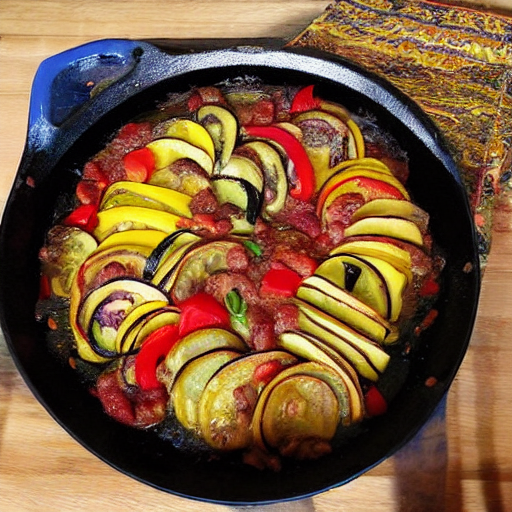

In [10]:
final_recipe[0]['Actual Recipe 1']
# from huggingface_hub import whoami
# print(whoami())
# pprint(final_recipe)
# with open("f.txt", "w") as f:
#     f.write(str(final_recipe))

In [1]:
!pip install -r /content/requirements.txt
